In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import time

print("Started ")
start_time = time.time()

data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)




Started 


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
# roc curve and auc score
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [24]:
## Apply RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
print('RF test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

RF train roc-auc: 1.0
RF test roc-auc: 0.956520410013908


In [25]:
# Apply Logistic Regression
from sklearn.linear_model import LogisticRegression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Logistic train roc-auc: 0.9132926837192907
Logistic test roc-auc: 0.9097619007250921


In [26]:
# Apply Adaboost Classifier
from sklearn.ensemble import AdaBoostClassifier
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Adaboost train roc-auc: 0.932570853497822
Adaboost test roc-auc: 0.9252959222101828


In [27]:
# Apply KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))

Adaboost train roc-auc: 0.9895028233016585
Adaboost test roc-auc: 0.9594150247665787


In [28]:
pred=[]
for model in [rf_model,log_classifier,ada_classifier,knn_classifier]:
    pred.append(pd.Series(model.predict_proba(X_test)[:,1]))
final_prediction=pd.concat(pred,axis=1).mean(axis=1)
print('Ensemble test roc-auc: {}'.format(roc_auc_score(y_test,final_prediction)))


Ensemble test roc-auc: 0.9619051760160537


In [29]:
final_prediction

0        0.155766
1        0.190304
2        0.837933
3        0.608590
4        0.866365
           ...   
12203    0.842314
12204    0.153584
12205    0.173935
12206    0.857416
12207    0.834287
Length: 12208, dtype: float64

In [30]:
#### Calculate the ROc Curve


fpr, tpr, thresholds = roc_curve(y_test, final_prediction)
thresholds

array([1.88038127, 0.88038127, 0.87174656, ..., 0.14496514, 0.14494993,
       0.12070247])

In [31]:
from sklearn.metrics import accuracy_score
accuracy_ls = []
for thres in thresholds:
    y_pred = np.where(final_prediction>thres,1,0)
    accuracy_ls.append(accuracy_score(y_test, y_pred, normalize=True))
    
accuracy_ls = pd.concat([pd.Series(thresholds), pd.Series(accuracy_ls)],
                        axis=1)
accuracy_ls.columns = ['thresholds', 'accuracy']
accuracy_ls.sort_values(by='accuracy', ascending=False, inplace=True)
accuracy_ls.head()

,thresholds,accuracy
1203,0.535293,0.916039
1300,0.474872,0.916039
1204,0.535174,0.915957
1202,0.535480,0.915957
1199,0.536233,0.915957


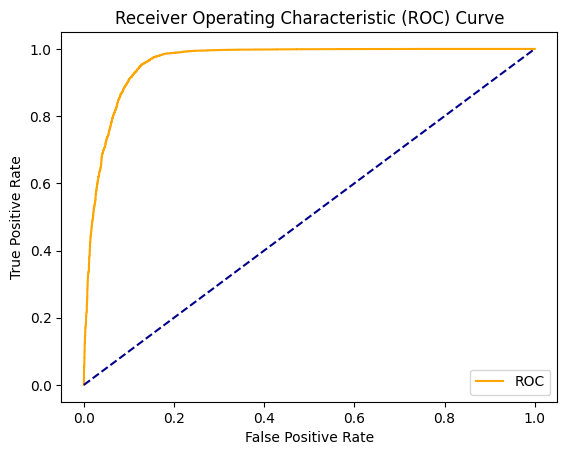

In [32]:
def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()
    
plot_roc_curve(fpr,tpr)

In [33]:
from sklearn import metrics
fpr, tpr, thresholds = metrics.roc_curve(y_test,y_pred)

In [34]:
thresholds

array([2, 1, 0])

In [37]:
def Find_Optimal_Cutoff(target, predicted):
    fpr, tpr, threshold = roc_curve(target, predicted)
    i = np.arange(len(tpr)) 
    roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'threshold' : pd.Series(threshold, index=i)})
    roc_t = roc.iloc[(roc.tf-0).abs().argsort()[:1]]

    return list(roc_t['threshold']) 

threshold = Find_Optimal_Cutoff(y_test,y_pred)

In [38]:
threshold

[1]

In [39]:
def plot_roc_curve(fpr,tpr, thresholds):
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % metrics.auc(fpr, tpr))
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")

    # create the axis of thresholds (scores)
    ax2 = plt.gca().twinx()
    ax2.plot(fpr, thresholds, markeredgecolor='r',linestyle='dashed', color='r')
    ax2.set_ylabel('Threshold',color='r')
    ax2.set_ylim([thresholds[-1],thresholds[0]])
    ax2.set_xlim([fpr[0],fpr[-1]])

    plt.savefig('roc_and_threshold.png')
    plt.close()

In [40]:
plot_roc_curve(fpr, tpr, thresholds)

In [41]:
!pip install tensorflow-macos

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.6/215.6 MB 16.1 MB/s eta 0:00:0000:0100:01
  Using cached termcolor-2.2.0-py3-none-any.whl (6.6 kB)
  Using cached absl_py-1.4.0-py3-none-any.whl (126 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 7.7 MB/s eta 0:00:00
  Using cached wrapt-1.15.0-cp310-cp310-macosx_11_0_arm64.whl (36 kB)
  Using cached typing_extensions-4.5.0-py3-none-any.whl (27 kB)
  Using cached grpcio-1.51.3-cp310-cp310-macosx_12_0_universal2.whl (8.2 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 54.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 53.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.2/439.2 kB 44.6 MB/s eta 0:00:00
  Preparing m

In [42]:
!pip install tensorflow-metal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.4 MB/s eta 0:00:00a 0:00:01


In [ ]:
import tensorflow as tf

cifar = tf.keras.datasets.cifar100
(x_train, y_train), (x_test, y_test) = cifar.load_data()
model = tf.keras.applications.ResNet50(
    include_top=True,
    weights=None,
    input_shape=(32, 32, 3),
    classes=100,)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer="adam", loss=loss_fn, metrics=["accuracy"])
model.fit(x_train, y_train, epochs=5, batch_size=64)

No Skill: ROC AUC=0.500
Logistic: ROC AUC=0.903


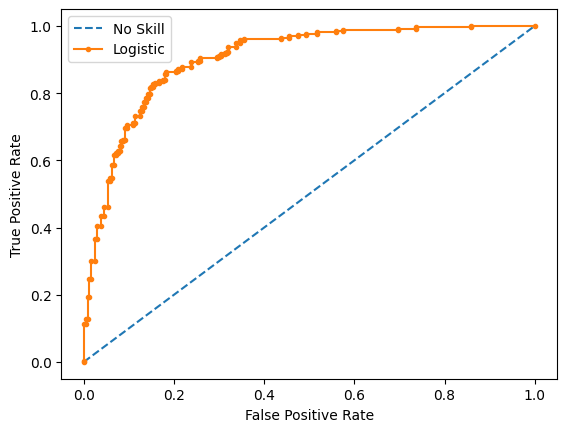

In [44]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
# generate 2 class dataset
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)
# split into train/test sets
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)
# generate a no skill prediction (majority class)
ns_probs = [0 for _ in range(len(testy))]
# fit a model
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)
# predict probabilities
lr_probs = model.predict_proba(testX)
# keep probabilities for the positive outcome only
lr_probs = lr_probs[:, 1]
# calculate scores
ns_auc = roc_auc_score(testy, ns_probs)
lr_auc = roc_auc_score(testy, lr_probs)
# summarize scores
print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('Logistic: ROC AUC=%.3f' % (lr_auc))
# calculate roc curves
ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)
# plot the roc curve for the model
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
RF train roc-auc: 1.0
ROC AUC=0.957


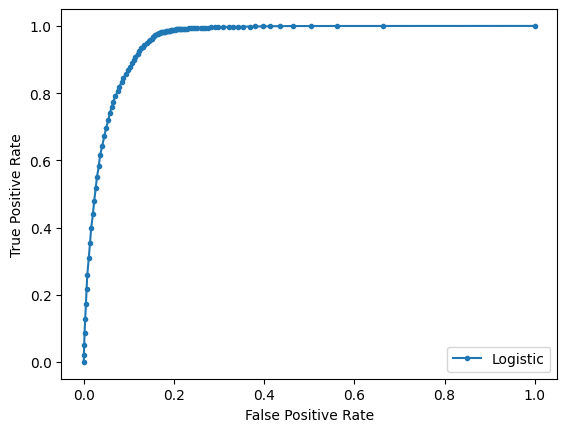

In [45]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import time

print("Started ")
start_time = time.time()

data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)




## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)


# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
# calculate scores
# ns_auc = roc_auc_score(y_test, ns_probs)
auc_score = roc_auc_score(y_test, ytest_pred)
# summarize scores
# print('No Skill: ROC AUC=%.3f' % (ns_auc))
print('ROC AUC=%.3f' % (auc_score))
# calculate roc curves
# ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
fpr, tpr, thresholds = roc_curve(y_test, ytest_pred)
# plot the roc curve for the model
# pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='No Skill')
pyplot.plot(fpr, tpr, marker='.', label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[6232 1221]
 [ 200 8624]]
F1 Score :  0.9238845144356956
RF test ROC AUC=0.958
Time Taken to train and test :  12.433097839355469
------------------------------------------------
Logistic train roc-auc: 0.9134340492559675
Logistic test roc-auc: 0.9096652561552546
Confusion Matrix :  [[6246 1207]
 [1017 7807]]
F1 Score :  0.8753223455544343
Time Taken to train and test :  9.475325107574463
------------------------------------------------
Adaboost train roc-auc: 0.9330424971611775
Adaboost test roc-auc: 0.9232175911931149
Confusion Matrix :  [[6165 1288]
 [ 892 7932]]
F1 Score :  0.8791842163600089
Time Taken to train and test :  4.87488317489624
------------------------------------------------
KNN train roc-auc: 0.9890818068029282
KNN test roc-auc: 0.9590639190240102
Confusion Matrix :  [[6680  773]
 [ 638 8186]]
F1 Score :  0.9206545577236687
Time Taken to train and test :  17.21152091026306
-------------------------------------------

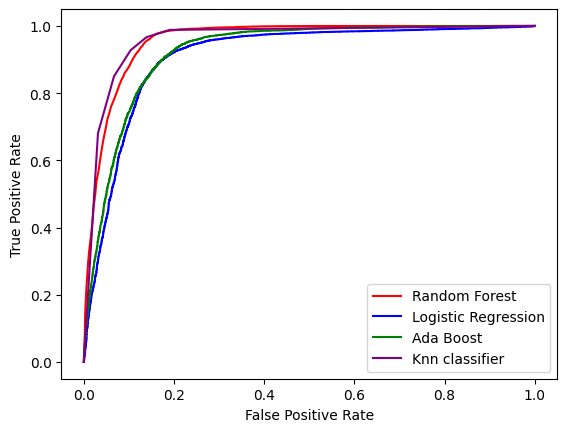

In [59]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier



print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("F1 Score : ", rf_f1_score)
# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[3087  617]
 [  85 4350]]
F1 Score :  0.9253350350989151
RF test ROC AUC=0.959
Time Taken to train and test :  16.66050386428833
------------------------------------------------
Logistic train roc-auc: 0.912697785200357
Logistic test roc-auc: 0.9104239665336356
Confusion Matrix :  [[3078  626]
 [ 483 3952]]
F1 Score :  0.8769555087096417
Time Taken to train and test :  10.117496252059937
------------------------------------------------
Adaboost train roc-auc: 0.9332299475143134
Adaboost test roc-auc: 0.9231071987747181
Confusion Matrix :  [[3079  625]
 [ 456 3979]]
F1 Score :  0.8804071246819339
Time Taken to train and test :  6.296538829803467
------------------------------------------------
KNN train roc-auc: 0.989686506611156
KNN test roc-auc: 0.9610952600680334
Confusion Matrix :  [[3311  393]
 [ 273 4162]]
F1 Score :  0.9259176863181313
Time Taken to train and test :  19.9522602558136
---------------------------------------------

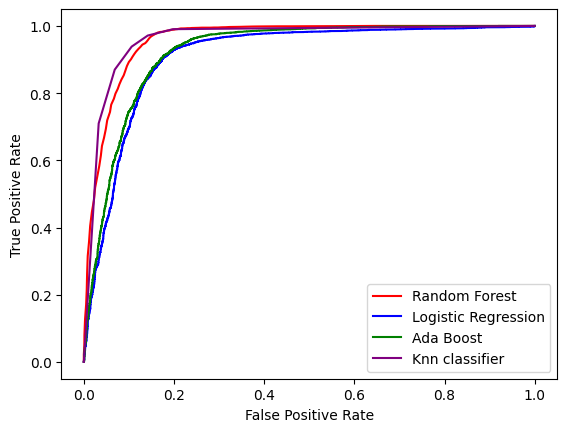

In [60]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier



print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("F1 Score : ", rf_f1_score)
# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

In [67]:
from sklearn.neural_network import MLPClassifier

print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

mlp = MLPClassifier(hidden_layer_sizes=(8,8,8), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_predict = mlp.predict_proba(X_train)
y_pred = mlp.predict(X_test)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)



Started 
(40692, 85)
(40692,)
MLP train roc-auc: 0.9545117190053667
MLP test roc-auc: 0.9454788814189116
Confusion Matrix :  [[3104  600]
 [ 168 4267]]
F1 Score :  0.9174371102988604


In [69]:
from sklearn.neural_network import MLPClassifier

print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

mlp = MLPClassifier(hidden_layer_sizes=(16,16,16), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_predict = mlp.predict_proba(X_train)
y_pred = mlp.predict(X_test)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)



Started 
(40692, 85)
(40692,)
MLP train roc-auc: 0.9634220582877847
MLP test roc-auc: 0.9532642123692112
Confusion Matrix :  [[3193  511]
 [ 253 4182]]
F1 Score :  0.9163014899211218


In [71]:
from sklearn.neural_network import MLPClassifier

print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

mlp = MLPClassifier(hidden_layer_sizes=(32,32,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_predict = mlp.predict_proba(X_train)
y_pred = mlp.predict(X_test)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)



Started 
(40692, 85)
(40692,)
MLP train roc-auc: 0.985662091566935
MLP test roc-auc: 0.9578853781889107
Confusion Matrix :  [[3287  417]
 [ 326 4109]]
F1 Score :  0.9170851467470148


In [72]:
from sklearn.neural_network import MLPClassifier

print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

mlp = MLPClassifier(hidden_layer_sizes=(64,32,16), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_predict = mlp.predict_proba(X_train)
y_pred = mlp.predict(X_test)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)



Started 
(40692, 85)
(40692,)
MLP train roc-auc: 0.9922839758651014
MLP test roc-auc: 0.9599569373796206
Confusion Matrix :  [[3247  457]
 [ 271 4164]]
F1 Score :  0.9196113074204947


In [73]:
from sklearn.neural_network import MLPClassifier

print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

mlp = MLPClassifier(hidden_layer_sizes=(128,64,64), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_predict = mlp.predict_proba(X_train)
y_pred = mlp.predict(X_test)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)



Started 
(40692, 85)
(40692,)
MLP train roc-auc: 0.9968913289968424
MLP test roc-auc: 0.9607789257355467
Confusion Matrix :  [[3344  360]
 [ 328 4107]]
F1 Score :  0.9227139968546394


In [74]:
from sklearn.neural_network import MLPClassifier

print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

mlp = MLPClassifier(hidden_layer_sizes=(128,128,128,128), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)



Started 
(40692, 85)
(40692,)
MLP train roc-auc: 0.9991395518481905
MLP test roc-auc: 0.9668706672575551
Confusion Matrix :  [[3325  379]
 [ 252 4183]]
F1 Score :  0.9298655107257976


In [62]:
print(predict_train)

[1 1 0 ... 0 1 0]


Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[3079  625]
 [  82 4353]]
F1 Score :  0.9248911080420695
RF test ROC AUC=0.959
Time Taken to train and test :  17.44460105895996
------------------------------------------------
Logistic train roc-auc: 0.912697785200357
Logistic test roc-auc: 0.9104239665336356
Confusion Matrix :  [[3078  626]
 [ 483 3952]]
F1 Score :  0.8769555087096417
Time Taken to train and test :  13.31815505027771
------------------------------------------------
Adaboost train roc-auc: 0.9332299475143134
Adaboost test roc-auc: 0.9231071987747181
Confusion Matrix :  [[3079  625]
 [ 456 3979]]
F1 Score :  0.8804071246819339
Time Taken to train and test :  6.327879905700684
------------------------------------------------
KNN train roc-auc: 0.989686506611156
KNN test roc-auc: 0.9610952600680334
Confusion Matrix :  [[3311  393]
 [ 273 4162]]
F1 Score :  0.9259176863181313
Time Taken to train and test :  20.335097789764404
--------------------------------------------

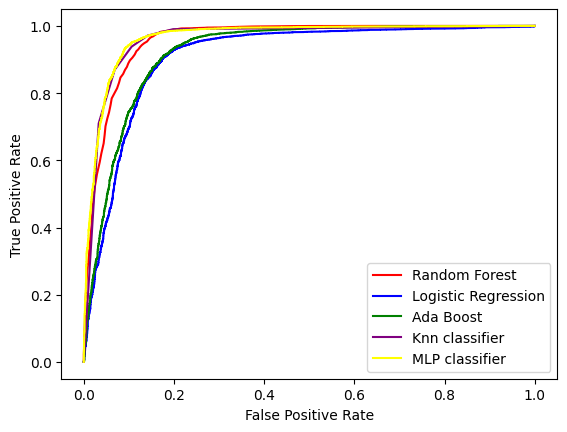

In [76]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier



print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("F1 Score : ", rf_f1_score)
# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")



# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

In [79]:
from sklearn import svm
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler



print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()


svm_clf = make_pipeline(StandardScaler(), svm.SVC(kernel='linear'))
svm_clf.fit(X_train,y_train)

# ytrain_pred = svm_clf.predict_proba(X_train)
# print('SVM train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
# ytest_pred = mlp.predict_proba(X_test)
# print('SVM test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# # Taking prediciton of positive class only
# ytest_pred = ytest_pred[:, 1]
# auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", svm_conf_matx)
print("F1 Score : ", svm_f1_score)


Started 
Confusion Matrix :  [[3034  670]
 [ 382 4053]]
F1 Score :  0.8851277571522166


In [1]:
from sklearn import svm
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler



print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()


svm_clf = make_pipeline(StandardScaler(), svm.SVC(gamma='auto'))
svm_clf.fit(X_train,y_train)

# ytrain_pred = svm_clf.predict_proba(X_train)
# print('SVM train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
# ytest_pred = mlp.predict_proba(X_test)
# print('SVM test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# # Taking prediciton of positive class only
# ytest_pred = ytest_pred[:, 1]
# auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", svm_conf_matx)
print("F1 Score : ", svm_f1_score)


Started 
Confusion Matrix :  [[3136  568]
 [  94 4341]]
F1 Score :  0.929152397260274


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler



print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()


print("Fitting the classifier to the training set")
param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'kernel': ['rbf', 'linear']}
clf = GridSearchCV(SVC(class_weight='balanced'), param_grid)
clf = clf.fit(X_train, y_train)
print("Best estimator found by grid search:")
print(clf.best_estimator_)

Started 
Fitting the classifier to the training set


Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[3075  629]
 [  88 4347]]
F1 Score :  0.9238125597704813
RF test ROC AUC=0.959
Time Taken to train and test :  16.962228059768677
------------------------------------------------
Logistic train roc-auc: 0.912697785200357
Logistic test roc-auc: 0.9104239665336356
Confusion Matrix :  [[3078  626]
 [ 483 3952]]
F1 Score :  0.8769555087096417
Time Taken to train and test :  9.592005968093872
------------------------------------------------
Adaboost train roc-auc: 0.9332299475143134
Adaboost test roc-auc: 0.9231071987747181
Confusion Matrix :  [[3079  625]
 [ 456 3979]]
F1 Score :  0.8804071246819339
Time Taken to train and test :  6.3040807247161865
------------------------------------------------
KNN train roc-auc: 0.989686506611156
KNN test roc-auc: 0.9610952600680334
Confusion Matrix :  [[3311  393]
 [ 273 4162]]
F1 Score :  0.9259176863181313
Time Taken to train and test :  19.575672149658203
------------------------------------------

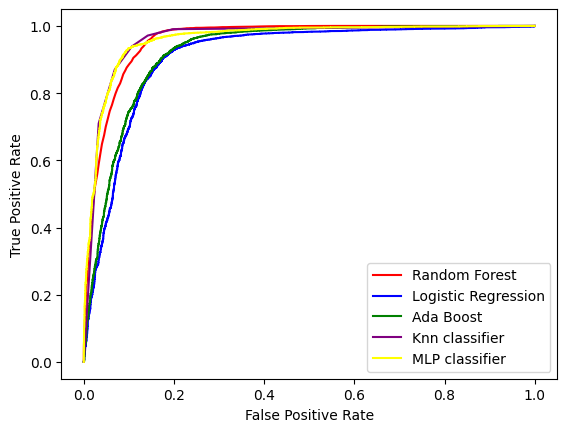

In [8]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("F1 Score : ", rf_f1_score)
# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")



# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

In [4]:
ls

conf_matrix_logistic_reg_1000.svg  random_forrest_3k_data.svg
logistic_10000_data.svg            random_forrest_40k_data.svg
logistic_1000_data.svg             roc_and_threshold.png
logistic_16k_data.svg              svm_linear_10k_data.svg
logistic_3000_data.svg             svm_linear_16k_data.svg
random_forrest_16k_data.svg        svm_linear_1k_data.svg
random_forrest_1k_data.svg         svm_linear_3k_data.svg
random_forrest_22k_data.svg


In [6]:
cd ..

/Users/bisalgt/Projects/playground


In [7]:
cd learn_redpitaya/

/Users/bisalgt/Projects/playground/learn_redpitaya


Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[6447 1576]
 [ 170 8934]]
F1 Score :  0.9109819516671767
RF test ROC AUC=0.946
Time Taken to train and test :  22.88727116584778
------------------------------------------------
Logistic train roc-auc: 0.8972472605464898
Logistic test roc-auc: 0.8914592837989727
Confusion Matrix :  [[6461 1562]
 [1008 8096]]
F1 Score :  0.8630209998934016
Time Taken to train and test :  24.835565090179443
------------------------------------------------
Adaboost train roc-auc: 0.9077569125959231
Adaboost test roc-auc: 0.8984896673382128
Confusion Matrix :  [[6366 1657]
 [ 829 8275]]
F1 Score :  0.869405337255726
Time Taken to train and test :  7.873035907745361
------------------------------------------------
KNN train roc-auc: 0.987845958805338
KNN test roc-auc: 0.9571039322470745
Confusion Matrix :  [[7099  924]
 [ 617 8487]]
F1 Score :  0.9167701863354037
Time Taken to train and test :  37.2285578250885
---------------------------------------------

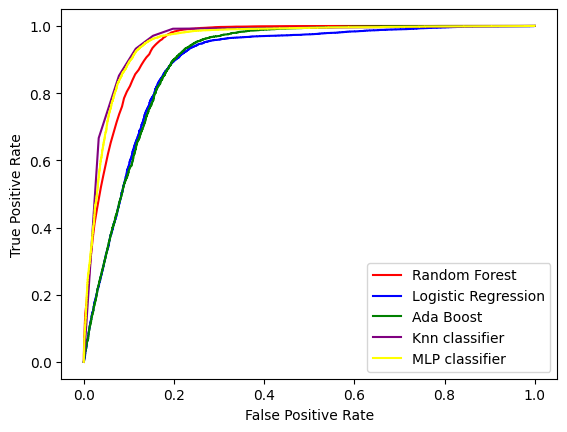

In [9]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle



print("Started ")


data = pd.read_csv("../learn_redpitaya/60k_dataframe.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("F1 Score : ", rf_f1_score)
# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")



# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

Started 
RF train roc-auc: 1.0
Confusion Matrix :  [[3074  630]
 [  96 4339]]
F1 Score :  0.9227988090174395
RF test ROC AUC=0.958
Time Taken to train and test :  17.592097997665405
------------------------------------------------
Logistic train roc-auc: 0.912697785200357
Logistic test roc-auc: 0.9104239665336356
Confusion Matrix :  [[3078  626]
 [ 483 3952]]
F1 Score :  0.8769555087096417
Time Taken to train and test :  9.718225002288818
------------------------------------------------
Adaboost train roc-auc: 0.9332299475143134
Adaboost test roc-auc: 0.9231071987747181
Confusion Matrix :  [[3079  625]
 [ 456 3979]]
F1 Score :  0.8804071246819339
Time Taken to train and test :  6.648808002471924
------------------------------------------------
KNN train roc-auc: 0.989686506611156
KNN test roc-auc: 0.9610952600680334
Confusion Matrix :  [[3311  393]
 [ 273 4162]]
F1 Score :  0.9259176863181313
Time Taken to train and test :  21.08547592163086
--------------------------------------------

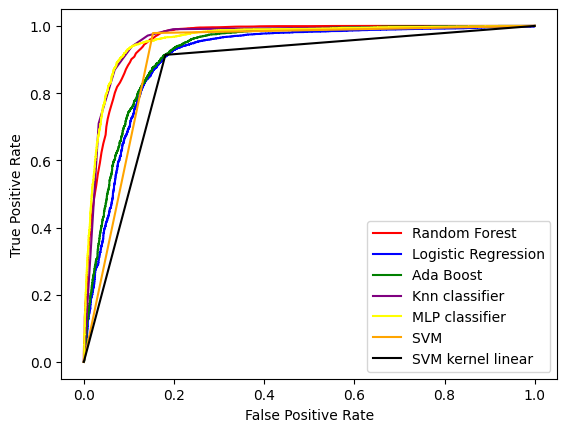

In [16]:
# roc curve and auc
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import pickle
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


print("Started ")


data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)


start_time = time.time()

## Apply RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
ytrain_pred = rf_model.predict_proba(X_train)
print('RF train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = rf_model.predict_proba(X_test)
# keep probabilities for the positive outcome only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = rf_model.predict(X_test)
rf_conf_matx = confusion_matrix(y_test, y_pred)
rf_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", rf_conf_matx)
print("F1 Score : ", rf_f1_score)

# summarize scores
print('RF test ROC AUC=%.3f' % (auc_score))
rf_fpr, rf_tpr, thresholds = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model40k/radom_forest_model.sav"
pickle.dump(rf_model, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Logistic Regression
log_classifier=LogisticRegression(max_iter=40000)
log_classifier.fit(X_train, y_train)
ytrain_pred = log_classifier.predict_proba(X_train)
print('Logistic train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = log_classifier.predict_proba(X_test)
print('Logistic test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = log_classifier.predict(X_test)
log_conf_matx = confusion_matrix(y_test, y_pred)
log_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", log_conf_matx)
print("F1 Score : ", log_f1_score)
# summarize scores
log_fpr, log_tpr, thresholds2 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model40k/logistic_model.sav"
pickle.dump(log_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply Adaboost 
ada_classifier=AdaBoostClassifier()
ada_classifier.fit(X_train, y_train)
ytrain_pred = ada_classifier.predict_proba(X_train)
print('Adaboost train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = ada_classifier.predict_proba(X_test)
print('Adaboost test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
temp = ytest_pred
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = ada_classifier.predict(X_test)
ada_conf_matx = confusion_matrix(y_test, y_pred)
ada_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", ada_conf_matx)
print("F1 Score : ", ada_f1_score)
# summarize scores
ada_fpr, ada_tpr, thresholds3 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model40k/ada_boost_model.sav"
pickle.dump(ada_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")

start_time = time.time()
# Apply KNN Classifier
knn_classifier=KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
ytrain_pred = knn_classifier.predict_proba(X_train)
print('KNN train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = knn_classifier.predict_proba(X_test)
print('KNN test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = knn_classifier.predict(X_test)
knn_conf_matx = confusion_matrix(y_test, y_pred)
knn_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", knn_conf_matx)
print("F1 Score : ", knn_f1_score)
# summarize scores
knn_fpr, knn_tpr, thresholds4 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model40k/knn_classifier_model.sav"
pickle.dump(knn_classifier, open(file_name, "wb"))

print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Neural Network, Multi Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', solver='adam', max_iter=500)
mlp.fit(X_train,y_train)

ytrain_pred = mlp.predict_proba(X_train)
print('MLP train roc-auc: {}'.format(roc_auc_score(y_train, ytrain_pred[:,1])))
ytest_pred = mlp.predict_proba(X_test)
print('MLP test roc-auc: {}'.format(roc_auc_score(y_test, ytest_pred[:,1])))
# Taking prediciton of positive class only
ytest_pred = ytest_pred[:, 1]
auc_score = roc_auc_score(y_test, ytest_pred)
#Confusion Matrix
y_pred = mlp.predict(X_test)
mlp_conf_matx = confusion_matrix(y_test, y_pred)
mlp_f1_score = f1_score(y_test, y_pred)
print("Confusion Matrix : ", mlp_conf_matx)
print("F1 Score : ", mlp_f1_score)
# summarize scores
mlp_fpr, mlp_tpr, thresholds5 = roc_curve(y_test, ytest_pred)
# Saving the model
file_name = "trained_model40k/mlp_model.sav"
pickle.dump(mlp, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier
svm_clf = make_pipeline(StandardScaler(), SVC(gamma='auto'))
svm_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_clf.predict(X_test)
svm_conf_matx = confusion_matrix(y_test, y_pred)
svm_f1_score = f1_score(y_test, y_pred)
print("SVM with gamma auto")
print("Confusion Matrix : ", svm_conf_matx)
print("F1 Score : ", svm_f1_score)
# summarize scores
svm_fpr, svm_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = "trained_model40k/svm_gamma_auto.sav"
pickle.dump(svm_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


start_time = time.time()
# Apply Support Vector Machine Classifier Kernel Linear
svm_lin_clf = make_pipeline(StandardScaler(), SVC(kernel="linear"))
svm_lin_clf.fit(X_train,y_train)

#Confusion Matrix
y_pred = svm_lin_clf.predict(X_test)
svm_lin_conf_matx = confusion_matrix(y_test, y_pred)
svm_lin_f1_score = f1_score(y_test, y_pred)
print("SVM with linear kernel")
print("Confusion Matrix : ", svm_lin_conf_matx)
print("F1 Score : ", svm_lin_f1_score)
# summarize scores
svm_lin_fpr, svm_lin_tpr, thresholds6 = roc_curve(y_test, y_pred)
# Saving the model
file_name = "trained_model40k/svm_kernel_linear.sav"
pickle.dump(svm_lin_clf, open(file_name, "wb"))


print("Time Taken to train and test : ", time.time() - start_time)
print("------------------------------------------------")


# plot the roc curve for the model
pyplot.plot(rf_fpr, rf_tpr, color="red", label='Random Forest')
pyplot.plot(log_fpr, log_tpr, color="blue", label='Logistic Regression')
pyplot.plot(ada_fpr, ada_tpr, color="green", label='Ada Boost')
pyplot.plot(knn_fpr, knn_tpr, color="purple", label='Knn classifier')
pyplot.plot(mlp_fpr, mlp_tpr, color="yellow", label='MLP classifier')
pyplot.plot(svm_fpr, svm_tpr, color="orange", label='SVM ')
pyplot.plot(svm_lin_fpr, svm_lin_tpr, color="black", label='SVM kernel linear ')

# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

# Hyper parameter tunning

In [5]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

# loading data and splitting
data = pd.read_csv("../learn_redpitaya/40k_dataframe_updated_label.csv", header=None)
X = data.iloc[:, 1:] # features
y = data.iloc[:, 0] # target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)



# Use the random grid to search for best hyperparameters
# First create the base model to tune
rf = RandomForestRegressor()
# Random search of parameters, using 3 fold cross validation, 
# search across 100 different combinations, and use all available cores
rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 1, cv = 2, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

print(rf_random.best_params_)



Fitting 2 folds for each of 1 candidates, totalling 2 fits
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 50, 'bootstrap': True}
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  29.1s
[CV] END bootstrap=True, max_depth=50, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  29.3s
